[*********************100%***********************]  1 of 1 completed


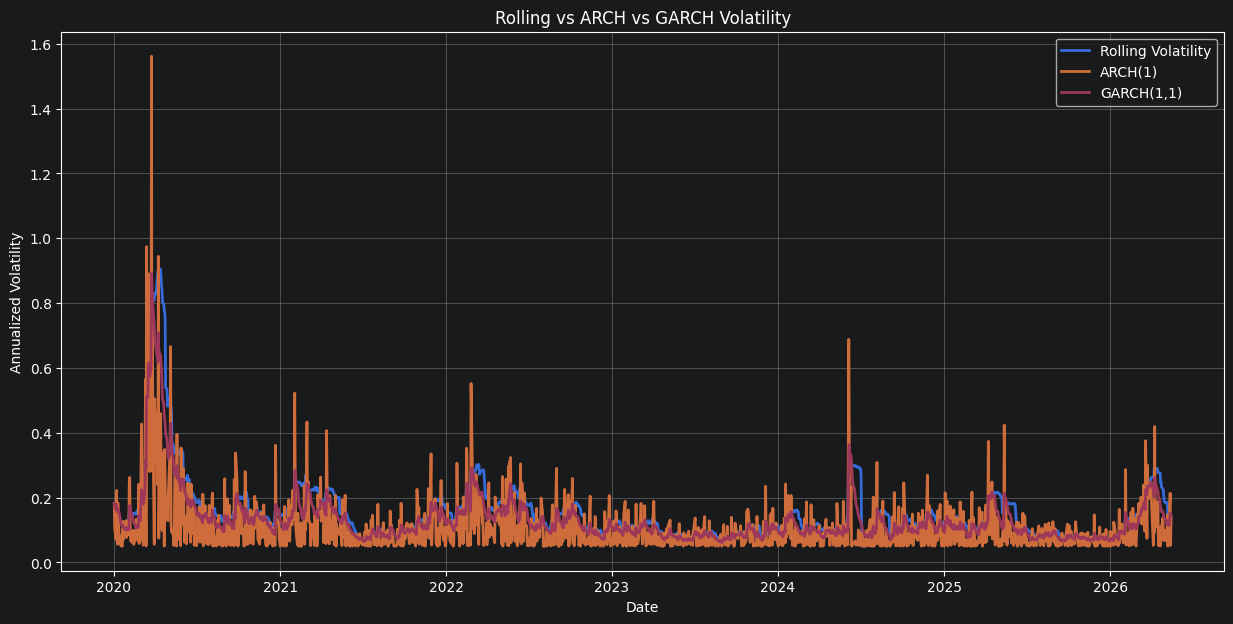

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------
# Download NIFTY data
# -----------------------------------
df = yf.download("^NSEI", start="2020-01-01")

# -----------------------------------
# Log Returns
# -----------------------------------
df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

returns = df["log_return"].dropna()

# -----------------------------------
# Rolling Volatility
# -----------------------------------
rolling_vol = (
    returns.rolling(20).std() * np.sqrt(252)
)

# -----------------------------------
# ARCH(1)
# -----------------------------------
omega_arch = 0.00001
alpha_arch = 0.5

arch_var = [returns.var()]

for r in returns[:-1]:

    new_var = (
        omega_arch
        + alpha_arch * r**2
    )

    arch_var.append(new_var)

arch_vol = np.sqrt(arch_var) * np.sqrt(252)

# -----------------------------------
# GARCH(1,1)
# -----------------------------------
omega_garch = 0.000001
alpha_garch = 0.10
beta_garch = 0.85

garch_var = [returns.var()]

for r in returns[:-1]:

    new_var = (
        omega_garch
        + alpha_garch * r**2
        + beta_garch * garch_var[-1]
    )

    garch_var.append(new_var)

garch_vol = np.sqrt(garch_var) * np.sqrt(252)

# -----------------------------------
# Align dataframe
# -----------------------------------
df = df.iloc[1:].copy()

df["rolling_vol"] = rolling_vol
df["arch_vol"] = arch_vol
df["garch_vol"] = garch_vol

# -----------------------------------
# Plot Comparison
# -----------------------------------
plt.figure(figsize=(15,7))

plt.plot(
    df.index,
    df["rolling_vol"],
    label="Rolling Volatility",
    linewidth=2
)

plt.plot(
    df.index,
    df["arch_vol"],
    label="ARCH(1)",
    linewidth=2
)

plt.plot(
    df.index,
    df["garch_vol"],
    label="GARCH(1,1)",
    linewidth=2
)

# -----------------------------------
# Styling
# -----------------------------------
plt.title("Rolling vs ARCH vs GARCH Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")

plt.legend()
plt.grid(True)

plt.show()